#COMPSCI 546: Applied Information Retrieval - Spring 2026 ([website](https://groups.cs.umass.edu/zamani/compsci-546-applied-information-retrieval-spring-2025/))
##Assignment 2: Text Processing and Indexing (Total : 100 points)

**Description**

This is a coding assignment where you will implement an inverted index with count information. Basic proficiency in Python is recommended.  

**Instructions**

* To start working on the assignment, you would first need to save the notebook to your local Google Drive. For this purpose, you can click on *Copy to Drive* button. You can alternatively click the *Share* button located at the top right corner and click on *Copy Link* under *Get Link* to get a link and copy this notebook to your Google Drive.  

*   For questions with descriptive answers, please replace the text in the cell which states "Enter your answer here!" with your answer. If you are using mathematical notation in your answers, please define the variables.
*   You should implement all the functions yourself and should not use a library or tool for the computation.
*   For coding questions, you can add code where it says "enter code here" and execute the cell to print the output.
* To create the final pdf submission file, execute *Runtime->RunAll* from the menu to re-execute all the cells and then generate a PDF using *File->Print->Save as PDF*.
Make sure that the generated PDF contains all the codes and printed outputs before submission.


**Submission Details**

* Due data: March 12, 2026 at 11:59 PM (ET).
* The final PDF must be uploaded on Gradescope.
* After copying this notebook to your Google Drive, please paste a link to it below. Use the same process given above to generate a link. ***You will not recieve any credit if you don't paste the link!*** Make sure we can access the file.
***LINK: https://colab.research.google.com/drive/1TqPKYFRm16i0SBOAeUNfdca9q_rHil-g?usp=sharing***

**Academic Honesty**

Please follow the guidelines under the *Collaboration and Help* section of the course website.     

# Download input files

Please execute the cell below to download the input files.

In [1]:
import os
import zipfile

# 1. Download files
!gdown 1IlmVkyzK7DAGsDBPAa_ahkRCoKwARVU0 -O HW02.zip

# 2. Extract the file (Same as your previous code)
with zipfile.ZipFile('HW02.zip', 'r') as zip_file:
    zip_file.extractall('./')

# 3. Cleanup and Setup
if os.path.exists('HW02.zip'):
    os.remove('HW02.zip')

Downloading...
From (original): https://drive.google.com/uc?id=1IlmVkyzK7DAGsDBPAa_ahkRCoKwARVU0
From (redirected): https://drive.google.com/uc?id=1IlmVkyzK7DAGsDBPAa_ahkRCoKwARVU0&confirm=t&uuid=596d1e53-bcf8-4843-bc75-1bd80d46763b
To: /content/HW02.zip
100% 32.5M/32.5M [00:00<00:00, 45.3MB/s]


In [2]:
# We will use HW02 as our working directory
os.chdir('HW02')

# Setting the input files
queries_file = "queries_tok_clean_kstem"
col = "antique-collection.tok.clean_kstem"
qrel_file = "test.qrel"

# 1 : Initial Data Setup (5 points)

We use files from the ANTIQUE dataset. The dataset consists of:
* **Collection file:** Contains passage IDs and text.
* **Query file:** Contains unique query IDs and pre-processed query text.
* **Qrel file:** Contains relevance judgments (ground truth) formatted as `queryid topicid passageid relevance_judgement`.

In the cell below, implement functions to load the queries and the query relevance (qrel) information into data structures.

In [3]:
from collections import defaultdict
'''
Load query file information into a data structure.
Return Variables:
queries - mapping from queryid to querytext
'''
def loadQueries(queries_file):
    # enter your code here
    queries = defaultdict(str)
    with open(queries_file, 'r', encoding='utf-8') as file:
      for line in file:
        processing_line = line.strip().split()
        query_id = processing_line[0]
        preprocessed_query = ' '.join(processing_line[1:])
        queries[query_id] = preprocessed_query

    return queries

    # return queries

'''
Load qrel file information into a data structure.
Return Variables:
num_queries - number of queries in the qrel file
qrels - query relevance information
'''
def loadQrels(qrel_file):
    # enter your code here
    num_queries, qrels = 0, defaultdict(list)

    with open(qrel_file, 'r', encoding='utf-8') as file:
      for line in file:


        # process for qrels
        processing_line = line.strip().split()
        query_id = processing_line[0]

        # Adding up for num_queries:
        if query_id not in qrels:
          num_queries += 1

        topic_id = processing_line[1]
        passage_id = processing_line[2]
        relevance_judgement = processing_line[3]
        qrels[query_id].append((topic_id, passage_id, relevance_judgement))

    return num_queries, qrels

queries = loadQueries(queries_file)
num_queries, qrels = loadQrels(qrel_file)

print('Total Num of queries in the query file : {0}'.format(len(queries) if 'queries' in locals() else 0))
print('Total Num of queries in the qrel file  : {0}'.format(num_queries if 'num_queries' in locals() else 0))

Total Num of queries in the query file : 15
Total Num of queries in the qrel file  : 15


# 2 : Inverted Index Construction (30 points)

As described in the previous assignment, this is a passage retrieval dataset and the collection consists of passages. Each row of the file consists of the following information:

*passage_id  passage_text*

The passage_id and passage_text information is tab ('\t') separated. The passage text has been pre-processed to remove punctutation, tokenised and stemmed using the Krovetz stemmer. The terms in the passage text can be accessed by splitting the text based on space.

## Question 2.1 (15 points)

In the cell below, you have to implement the following:

1) Create new integer passage ids ranging from [1-num of passages in the collection], corresponding to each passageId given in the input collection file, for eg: the passageId in the first row would correspond to 1, the one on the second row would correspond to 2 and so on. Please store this in a data structure which could be accessed in subsequent cells. Please note that the collection could contain passageIds with no corresponding text information. While reading the collection file, you may need to handle this scenario.

2) An inverted index with count information. An example is given in Section 5.3.2 of the reference book : "Search Engines: Information Retrieval in Practice". A typical entry (posting) in this type of inverted index would consist of a term followed by the set of passages in which it occurs along with number of times it occured within each of them. For eg: if a term "fish" occured in two passages with ids: "4" and "10" and corresponding frequencies "1" and "2", the entry for "fish" would look like this.

*fish  4:1 10:2*

Please note that the passage ids within the index must correspond to the newly created passage ids. For a particular term, the passage ids must be sorted in ascending order (small->large), like the example given above (where "4" is less than "10").

Besides the term count information, the index must also contain the statistics such as total number of tokens in the collections and total number of unique terms.

Real-world indices are typically very large and cannot be stored in memory, however the collection provided for this assignment is fairly small and can be easily loaded into memory.

In [4]:
from collections import defaultdict
from typing import Counter

'''
In this function, create inverted index with count information
Return Variables:
indexCount - Datastructure used for holding the inverted index with count information.
            Please note that besides the term posting list, you must also store information
            such as total number of tokens in the collections, total number of unique terms
            and total number of unique passages in the collection (This would also include any
            potential passagIds with empty text).
numPassages - Total number of unique passages in the collection.
            You can return the count stored within the index.
docMap - datastructure which maps newly created passage ids to original passage ids.
        ie eg: 1 ->"2020338_0", 2->"2020338_1"
'''
# TODO: add statistics, include passages with empty text, check on sorting property!
def createIndexCount(col):
    indexCount = {}
    numPassages = 0
    docMap = defaultdict(str)

    cur_id = 1
    passage_id_to_new_id = {}
    indexCountDict = defaultdict(dict)

    # statistic variables
    total_tokens = 0
    unique_terms = 0

    with open(col, 'r', encoding='utf-8') as file:
      for line in file:
        processing_line = line.strip().split("\t")
        passage_id = processing_line[0]
        new_id = None

        if passage_id not in passage_id_to_new_id:
          passage_id_to_new_id[passage_id] = cur_id
          docMap[cur_id] = passage_id
          numPassages += 1

          new_id = cur_id
          cur_id += 1
        else:
          new_id = passage_id_to_new_id[passage_id]

        if len(processing_line) > 1:
          cur_passage = processing_line[1].split()
          # summing total tokens:
          total_tokens += len(cur_passage)

          # adding to index
          for word in cur_passage:
            indexCountDict[word][new_id] = indexCountDict[word].get(new_id, 0) + 1

    # Postprocessing for indexCount
    for word in indexCountDict.keys():
      dict_value = indexCountDict[word]

      indexCount[word] = sorted(dict_value.items(), key=lambda item: item[0])

    indexCount["total_tokens"] = total_tokens
    indexCount["unique_terms"] = len(indexCountDict)
    indexCount["num_passages"] = numPassages

    return indexCount, numPassages, docMap
indexCount, numPassages, docMap = createIndexCount(col)

#sanity check
print ('Total number of passages in the collection :{0}'.format(numPassages))

Total number of passages in the collection :403492


## Question 2.2 (3 points)

Please give a short description of your implementation of the index including how the postings are stored within the index.  

**Answer:**\
The inverted index is constructed by scanning the collection file line by line. Each passage is assigned a new integer identifier starting from 1, and a mapping from the new identifier to the original passage ID is stored in `docMap`.

For each passage, the text is tokenized by splitting on whitespace. For each term, the index stores a posting consisting of the new passage ID and the term frequency within that passage.

During indexing, a temporary dictionary maps each term to a dictionary of `(docID → term frequency)`. After processing the collection, each term’s postings are converted into a list of `(docID, tf)` tuples sorted by ascending document ID.

The index also stores collection statistics including the total number of tokens and the number of unique terms.

## Question 2.3 (10 points)

In the cell below, you have to implement an index with delta encoding. Please note that delta encoding is done only for passage ids and not for term count information. Instead of reading through the entire collection file again, you can use the index created above to generate the new index.

In [5]:
'''
In this function, create inverted index with count information and delta encoded passage ids.
Return Variables:
indexDelta - Datastructure used for holding the new inverted index with count information.
             Please note that you must also store information such as total number of tokens,
             total number of unique terms and total number of unique passages in the collection.
             (This would also include any potential passagIds with empty text)
numPassages - Total number of unique passages in the collection.
              You can return the count stored within the index.
'''
def createIndexDeltaCount(indexCount):
    # DS init
    indexDelta = {}


    for key, value in indexCount.items():
      # If key is statistics values
      if key == "total_tokens" or key == "unique_terms" or key == "num_passages":
        continue
      curSum = 0
      deltaList = [() for _ in range(len(value))]

      # Classic prefix sum
      for i in range(len(value)):
        passageId = value[i][0]
        frequency = value[i][1]
        deltaList[i] = (passageId - curSum, frequency)
        curSum = passageId
      indexDelta[key] = deltaList

    # Store special statistic
    indexDelta["total_tokens"] = indexCount["total_tokens"]
    indexDelta["unique_terms"] = indexCount["unique_terms"]
    indexDelta["num_passages"] = indexCount["num_passages"]

    numPassages = indexCount["num_passages"]

    return indexDelta, numPassages

''' this is an example. You can return additional information based on your implementation.'''
indexDelta, numPassages = createIndexDeltaCount(indexCount)

#sanity check
print ('Total number of passages in the collection :{0}'.format(numPassages))

Total number of passages in the collection :403492


## Question 2.4 (2 points)

Please give a short description of delta encoding.

**Answer:**\
Delta encoding is a compression technique used in inverted indexes to reduce the storage required for posting lists. Since document IDs in a posting list are stored in ascending order, instead of storing the full document IDs, we store the difference between the current document ID and the previous one.

For the first document in the posting list, the value is stored as is. For subsequent documents, the stored value is the difference between the current document ID and the previous document ID. This produces smaller numbers that can be stored more efficiently. In this implementation, only passage IDs are delta encoded, while the term frequency values remain unchanged.

# 3 : Zipf's Law Analysis (15 points)

## Question 3.1 (2 points):

Briefly describe Zipf's law.

Zipf's law (named after George Kingsley Zipf) is an empirical law describing the total frequency of a token in a corpus $(f_r)$ as a function of its rank $(r)$ by its frequency in the corpus.
$$f_r = \frac{k}{r}$$
$$\log(f_r) = -\log(r) + log(k)$$


## Question 3.2 (10 points)

In the cell below, find the frequency of terms in the vocabulary. Convert these to probability values by dividing the term frequency by the total number of tokens.  Also display the rank*probability values for the top 20 most frequent terms (sorted with respect to their frequency in descending order) where rank corresponds to the frequency ranking of the terms.


In [6]:
'''
In this function, calculate term probability and rank*probability values.
Return Variables:
termProb - term probabilities of all terms in the vocabulary
rtermProb -  product of rank and probabilities of top 20 most frequent terms
'''
def zipf(indexCount):
  #enter your code here
  termProb = {}
  rtermProb = []

  for word, frequencyList in indexCount.items():
    if word == "total_tokens" or word == "unique_terms" or word == "num_passages":
      continue
    wordOccurance = sum(freq for _, freq in frequencyList)
    termProb[word] = wordOccurance / indexCount["total_tokens"]

  sortedProb = sorted(termProb.items(), key=lambda item: item[1], reverse=True)[:20]
  for i in range(len(sortedProb)):
    rtermProb.append((i + 1, sortedProb[i][0], (i+1) * sortedProb[i][1])) # rank, term, rankProb

  return  termProb, rtermProb

# You can pass any additional variables needed for the calculation
termProb, rtermProb = zipf(indexCount)

'''print the rank* term probabilities. Please make that the final pdf displays all the outputs.
'''
print ('rank * Term Frequency Prob Values for top 20 most frequent terms:')
for r in rtermProb:
  print (r)


rank * Term Frequency Prob Values for top 20 most frequent terms:
(1, 'the', 0.04563558762938548)
(2, 'to', 0.05512024461398776)
(3, 'and', 0.07475218439574982)
(4, 'a', 0.09750563243996088)
(5, 'you', 0.10236522996876984)
(6, 'of', 0.11890158062748067)
(7, 'it', 0.13207338588408707)
(8, 'is', 0.142201801958848)
(9, 'in', 0.12853301227355637)
(10, 'that', 0.13456192465161512)
(11, 'i', 0.13849078396777056)
(12, 'are', 0.1114752046964034)
(13, 'do', 0.11339189491633452)
(14, 'for', 0.11708398590794475)
(15, 'they', 0.12210898371235251)
(16, 'have', 0.12501271092679186)
(17, 'your', 0.125374313059925)
(18, 'or', 0.12743500519618467)
(19, 'be', 0.1297767693022393)
(20, 'not', 0.13407910533399614)


## Question 3.3 (3 points)

In the cell below, use the term probability and rank information of all terms in the vocabulary calculated in the previous question, and plot a graph with the log(probability) as y-axis and log(rank) as x-axis where rank corresponds to the frequency ranking of the terms. This must be plotted for all the terms.

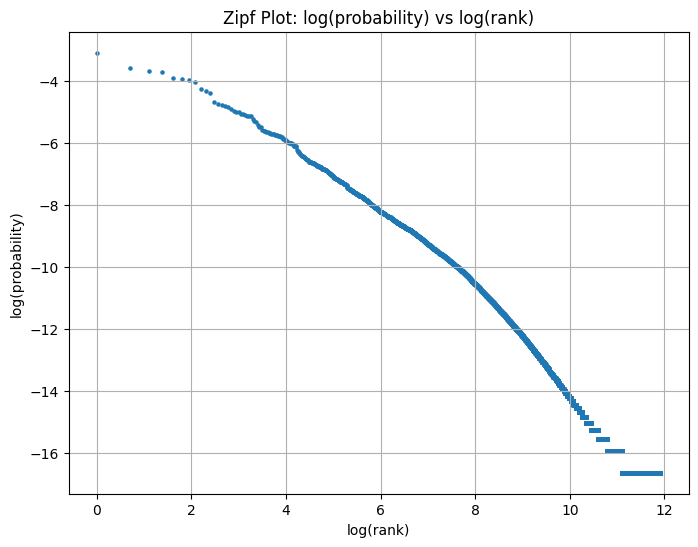

In [7]:
# enter code here to plot the curve
import math
import matplotlib.pyplot as plt

# termProb already computed from your zipf(indexCount)
# termProb: {term: probability}

# Build (rank, prob) for ALL terms (rank by descending probability)
sorted_all = sorted(termProb.items(), key=lambda x: x[1], reverse=True)

ranks = []
probs = []

for i, (term, p) in enumerate(sorted_all, start=1):
    # safety: avoid log(0) just in case (shouldn't happen if p>0)
    if p > 0:
        ranks.append(i)
        probs.append(p)

# log-log values
log_ranks = [math.log(r) for r in ranks]
log_probs  = [math.log(p) for p in probs]

plt.figure(figsize=(8, 6))
plt.scatter(log_ranks, log_probs, s=5)
plt.xlabel("log(rank)")
plt.ylabel("log(probability)")
plt.title("Zipf Plot: log(probability) vs log(rank)")
plt.grid(True)
plt.show()

# 4 : Retrieval Models (30 points)

Before implementing the retrieval models, we need to extract the required document statistics (`doclen`, `avgdl`, `probctf`) from the `indexCount` and `termProb` data structures you built in Sections 2 and 3.

In [8]:
# your code here
doclen = defaultdict(int)
avgdl = 0
probctf = {}

# calculating length of passage in a single document
for word, freq in indexCount.items():
  if word == "total_tokens" or word == "unique_terms" or word == "num_passages":
      continue

  for passageId, frequency in freq:
    doclen[passageId] += frequency

# calculating avgdl
numToken = indexCount["total_tokens"]
numPassages = indexCount["num_passages"]
avgdl = numToken / numPassages

# calculating probability of collection term frequency
probctf = termProb


In [9]:
print ('Total number of passages in the collection :{0}'.format(numPassages))
print('Average passage length :{0}'.format(avgdl))
print('Total num of unique terms :{0}'.format(indexCount['unique_terms']))
print('Total num of terms in the collection :{0}'.format(indexCount['total_tokens']))

Total number of passages in the collection :403492
Average passage length :41.11619809066846
Total num of unique terms :149467
Total num of terms in the collection :16590057


## 5.1: Vector Space Model (VSM) (10 points)

In the cell below, implement the VSM model given in Slide 19 of 'Basic Retrieval Models Part 1'. The score function has been given below for reference.

$$ score(q,p) = \sum_{w \in {q \cap p}} count(w,q) \frac{ln(1+ln(1+count(w,p)))}{1-b+b \frac{|p|}{avgdl}} ln \frac{|C|+1}{df(w)} $$

$score(q,p)$ - score assigned to a passage $p$ for a query $q$

$count(w,q)$ - number of times term $w$ occurs in query $q$

$count(w,p)$ - number of times term $w$ occurs in passage $p$

$b$ - set this to 0.75

$|p|$ - Number of tokens in passage $p$

$avgdl$ - Average number of tokens in passages in collection

$|C|$ - number of passages in collection $C$

$df(w)$ - number of passages containing term $w$

Please note that we consider each query term once, since this is equivalent to a dot product.

For each query, you have to return the top 5 retrieved passages ranked based on the score returned by the VSM model using "term at a time" scoring method.


In [10]:
# from typing_extensions import final
from collections import Counter
import math

# constants
b = 0.75

def vsm(queries, index, avgdl, num_passages, doclen):
    # DS init
    final_ranking_vsm = defaultdict(list)

    for id, query in queries.items():
      score_dic = defaultdict(float)
      # process query:
      arr_query = query.split()
      query_counter = Counter(arr_query)

      for term, freq_query in query_counter.items():
        if term not in index: continue

        df = len(index[term])

        for docID, tf in index[term]:
          score = freq_query * (math.log(1 + math.log(1 + tf))) / (1 - b + b*(doclen[docID]) / avgdl) * math.log((num_passages + 1) / df)

          score_dic[docID] += score

      # sort by score and get top 5 for that single query
      sorted_score = sorted(score_dic.items(), key=lambda x: x[1], reverse=True)
      final_ranking_vsm[id] = [docID for docID, _ in sorted_score[:5]]

    return final_ranking_vsm

final_ranking_vsm = vsm(queries, indexCount, avgdl, numPassages, doclen)
print('Top retrieved passage for query id "3698636" (VSM): {0}'.format(final_ranking_vsm.get('3698636', [])[:1] if 'final_ranking_vsm' in locals() else []))

Top retrieved passage for query id "3698636" (VSM): [385724]


## 5.2: BM25 (10 points)

In the cell below, implement the BM25 model given in slide 31 of 'Basic Retrieval Models Part 3'.

$$score(q,p) = \sum_{w \in {q \cap p}} \frac{(k_1+1) count(w,p)}{k_1(1-b+b(\frac{|p|}{avgdl})) + count(w,p)} ln\frac{|C|-df(w)+0.5}{df(w)+0.5}$$


$score(q,p)$ - score assigned to a passage $p$ for a query $q$

$count(w,p)$ - number of times term $w$ occurs in passage $p$

$b$ - set this to 0.75

$|p|$ - Number of tokens in passage $p$

$avgdl$ - Average number of tokens in passages in collection

$|C|$ - number of passages in collection $C$

$df(w)$ - number of passages containing term $w$

$k_1$ - set to 1.2

Please note that we iterate over all query tokens including repetitions.

Similar to the previous model, return the top 5 retrieved passages for each query ranked based on the BM25 scoring using "term at a time" scoring method.

In [11]:
# Constants
k1 = 1.2
b = 0.75

def bm25(queries, index, avgdl, num_passages, doclen):
    # enter your code here
    final_ranking_bm25 = defaultdict(list)

    for id, query in queries.items():
      score_dic = defaultdict(float)
      # process query:
      arr_query = query.split()

      for term in arr_query:
        if term not in index: continue

        df = len(index[term])

        for docID, tf in index[term]:
          score = ((k1 + 1) * tf) / (k1 * (1 - b + b * (doclen[docID] / avgdl)) + tf) * math.log((num_passages - df + 0.5) / (df + 0.5))
          score_dic[docID] += score

      # sort by score and get top 5 for every single query:
      sorted_score = sorted(score_dic.items(), key=lambda x: x[1], reverse=True)
      final_ranking_bm25[id] = [docID for docID, _ in sorted_score[:5]]

    return final_ranking_bm25

final_ranking_bm25 = bm25(queries, indexCount, avgdl, numPassages, doclen)
print('Top retrieved passage for query id "3698636" (BM25): {0}'.format(final_ranking_bm25.get('3698636', [])[:1] if 'final_ranking_bm25' in locals() else []))

Top retrieved passage for query id "3698636" (BM25): [152010]


## 5.3: Query Likelihood Model (10 points)

In the cell below, implement the Query  Likelihood model using the Jelinek-Mercer (JM) Smoothing technique. The score can be computed as follows:

   
   $$score(q,p) = \sum_{w \in {q}} ln( (1-\lambda) P_{MLE}(w|p) + \lambda P_{MLE}(w|C))$$

$score(q,p)$ - score assigned to a passage $p$ for a query $q$

 $P_{MLE}(w|p)$ = $\frac{count(w,p)}{|p|}$

 $P_{MLE}(w|C)$ = $\frac{count(w,C)}{N}$

$count(w,p)$ - number of times term $w$ occurs in passage $p$

$count(w,C)$ - number of times term $w$ occurs in collection $C$

$|p|$ - Number of tokens in passage $p$


$N$ - Number of tokens in collection $C$

$\lambda$ - set to 0.2

Please note that we iterate over all query tokens including repetitions.

Similar to the previous model, return the top 5 retrieved passages for each query ranked based on the QL scoring using "term at a time" scoring method. .

In [12]:
# imports
from collections import Counter

# Constants
LAMBDA = 0.2

def ql_jm(queries, index, doclen, probctf):
    # enter your code here
    final_ranking_ql_jm = defaultdict(list)

    for id, query in queries.items():
      score_dic = defaultdict(float)

      # process query:
      arr_query = query.split()

      # candidate docs = union of postings of query terms
      candidate_docs = set()
      for word in arr_query:
        if word in index:
          for docID, _ in index[word]:
            candidate_docs.add(docID)

      # for each query term, first add background score to all candidate docs
      for word in arr_query:
        if word not in probctf:
          continue

        bg = math.log(LAMBDA * probctf[word])

        for docID in candidate_docs:
          score_dic[docID] += bg

        if word in index:
          for docID, tf in index[word]:
            full_score = math.log((1 - LAMBDA) * (tf / doclen[docID]) + LAMBDA * probctf[word])
            score_dic[docID] += (full_score - bg)

      # get the top 5 and store to final ranking ql jm
      sorted_score = sorted(score_dic.items(), key=lambda x: x[1], reverse=True)
      final_ranking_ql_jm[id] = [docID for docID, _ in sorted_score[:5]]

    return final_ranking_ql_jm

final_ranking_ql_jm = ql_jm(queries, indexCount, doclen, probctf)
print('Top retrieved passage for query id "3698636" (QL): {0}'.format(final_ranking_ql_jm.get('3698636', [])[:1] if 'final_ranking_ql_jm' in locals() else []))

Top retrieved passage for query id "3698636" (QL): [152010]


# 6 : Evaluation (10 points)

Evaluate the top 5 retrieved passages corresponding to each of the models using Precision@5 and Recall@5 metrics.

In [13]:
def calcPrecision(top, qrels, rank_in):
  #enter your code here
  precision = 0.0
  for qid, rank in rank_in.items():
    precision_query = 0

    # qrels[qid] is a list of tuples: (topic_id, passage_id, relevance)
    relevance_passages = set()

    for _, passage_id, relevance in qrels[qid]:
      if int(relevance) >= 3: # in case we haven't convert
        relevance_passages.add(passage_id)

    for doc_id in rank[:top]:
      original_passage_id = docMap[doc_id]
      if original_passage_id in relevance_passages:
        precision_query += 1

    precision += precision_query / top

  return precision / len(rank_in)

def calcRecall(top, qrels, rank_in):
  #enter your code here
  recall = 0.0

  for qid, rank in rank_in.items():
    recall_query = 0

    # build set of relevant passages for this query:
    relevant_passages = set()

    for _, passage_id, relevance in qrels[qid]:
      if int(relevance) >= 3:
        relevant_passages.add(passage_id)

    # avoid divide-by-zero just in case
    if len(relevant_passages) == 0: continue

    for doc_id in rank[:top]:
      original_passage_id = docMap[doc_id]
      if original_passage_id in relevant_passages:
        recall_query += 1

    recall += recall_query / len(relevant_passages)

  return recall / len(rank_in)

if 'final_ranking_vsm' in locals() and 'qrels' in locals():

    # Hint: Precision value interval [0.1,0.2],  Recall value interval [0.04,0.05]
    print("Evaluate VSM model")
    print('Precision at top 5 : {0}'.format(calcPrecision(5, qrels, final_ranking_vsm)))
    print('Recall at top 5 : {0}'.format(calcRecall(5, qrels, final_ranking_vsm)))
    print("*********************************************************************")

    # Hint: Precision value interval [0.3,0.4], Recall value interval [0.10,0.20]
    print("Evaluate BM25 model")
    print('Precision at top 5 : {0}'.format(calcPrecision(5, qrels, final_ranking_bm25)))
    print('Recall at top 5 : {0}'.format(calcRecall(5, qrels, final_ranking_bm25)))
    print("*********************************************************************")

    # Hint: Precision value interval [0.3,0.4], Recall value interval [0.1,0.2]
    print("Evaluate QL model with Jelinek-Mercer smoothing")
    print('Precision at top 5 : {0}'.format(calcPrecision(5, qrels, final_ranking_ql_jm)))
    print('Recall at top 5 : {0}'.format(calcRecall(5, qrels, final_ranking_ql_jm)))
    print("*********************************************************************")

Evaluate VSM model
Precision at top 5 : 0.16
Recall at top 5 : 0.04649035880919939
*********************************************************************
Evaluate BM25 model
Precision at top 5 : 0.36000000000000004
Recall at top 5 : 0.12100747347124159
*********************************************************************
Evaluate QL model with Jelinek-Mercer smoothing
Precision at top 5 : 0.33333333333333337
Recall at top 5 : 0.11713800960177773
*********************************************************************


# 7 : Analysis (10 points)

## 7.1: (5 points)

While aggregate metrics like Precision@5 and Recall@5 are useful, they hide the individual strengths and weaknesses of different retrieval algorithms. In this section, you will compare VSM and BM25 on a query-by-query basis.

**Task:**
1. Identify a query in the dataset where the Vector Space Model (VSM) strictly outperforms BM25 in Precision@5 (i.e., VSM P@5 > BM25 P@5).
2. For that specific query, retrieve the top 1 passage ranked by VSM and the top 1 passage ranked by BM25. Print the query text and both passage texts.
3. In a few sentences, explain *why* BM25 failed to rank the relevant passage higher than the non-relevant one, while VSM succeeded. Reference the specific term frequencies (TF), document lengths, or the mathematical formulations of the two algorithms (e.g., TF saturation, length normalization) to justify your answer.

In [17]:
def precision_at_k_single_query(top, qid, qrels, rank_in, docMap):
    relevant_passages = set()
    for _, passage_id, relevance in qrels[qid]:
        if int(relevance) >= 3:
            relevant_passages.add(passage_id)

    hits = 0
    for doc_id in rank_in[qid][:top]:
        original_passage_id = docMap[doc_id]
        if original_passage_id in relevant_passages:
            hits += 1

    return hits / top


def load_collection_texts(col_file):
    passage_texts = {}
    with open(col_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t', 1)
            passage_id = parts[0]
            passage_text = parts[1] if len(parts) > 1 else ""
            passage_texts[passage_id] = passage_text
    return passage_texts


# find a query where:
# 1) VSM strictly beats BM25 in P@5
# 2) top-1 passage is different between VSM and BM25
chosen_qid = None
chosen_vsm_p5 = None
chosen_bm25_p5 = None

for qid in queries.keys():
    vsm_p5 = precision_at_k_single_query(5, qid, qrels, final_ranking_vsm, docMap)
    bm25_p5 = precision_at_k_single_query(5, qid, qrels, final_ranking_bm25, docMap)

    vsm_top1_orig = docMap[final_ranking_vsm[qid][0]]
    bm25_top1_orig = docMap[final_ranking_bm25[qid][0]]

    if vsm_p5 > bm25_p5 and vsm_top1_orig != bm25_top1_orig:
        chosen_qid = qid
        chosen_vsm_p5 = vsm_p5
        chosen_bm25_p5 = bm25_p5
        break

if chosen_qid is None:
    print("No query found where VSM strictly beats BM25 and top-1 differs.")
else:
    passage_texts = load_collection_texts(col)

    vsm_top1_newid = final_ranking_vsm[chosen_qid][0]
    bm25_top1_newid = final_ranking_bm25[chosen_qid][0]

    vsm_top1_orig = docMap[vsm_top1_newid]
    bm25_top1_orig = docMap[bm25_top1_newid]

    print("Chosen query ID:", chosen_qid)
    print("Query text:", queries[chosen_qid])
    print("VSM P@5:", chosen_vsm_p5)
    print("BM25 P@5:", chosen_bm25_p5)
    print()

    print("Top-1 passage ranked by VSM:")
    print("Passage ID:", vsm_top1_orig)
    print("Passage text:", passage_texts[vsm_top1_orig])
    print()

    print("Top-1 passage ranked by BM25:")
    print("Passage ID:", bm25_top1_orig)
    print("Passage text:", passage_texts[bm25_top1_orig])

No query found where VSM strictly beats BM25 and top-1 differs.


In [18]:
chosen_qid = None

for qid in queries.keys():
    vsm_p5 = precision_at_k_single_query(5, qid, qrels, final_ranking_vsm, docMap)
    bm25_p5 = precision_at_k_single_query(5, qid, qrels, final_ranking_bm25, docMap)

    vsm_top5_orig = [docMap[d] for d in final_ranking_vsm[qid][:5]]
    bm25_top5_orig = [docMap[d] for d in final_ranking_bm25[qid][:5]]

    if vsm_p5 > bm25_p5 and vsm_top5_orig != bm25_top5_orig:
        chosen_qid = qid
        print("Chosen query ID:", qid)
        print("Query text:", queries[qid])
        print("VSM P@5:", vsm_p5)
        print("BM25 P@5:", bm25_p5)
        print("VSM top5:", vsm_top5_orig)
        print("BM25 top5:", bm25_top5_orig)
        break

Chosen query ID: 1262692
Query text: how can i get rid of pimple on my back
VSM P@5: 0.4
BM25 P@5: 0.2
VSM top5: ['866587_0', '3536820_13', '4200715_1', '3335691_1', '940641_8']
BM25 top5: ['866587_0', '3958656_1', '1985026_0', '1382201_6', '1219612_3']


In [19]:
def load_collection_texts(col_file):
    passage_texts = {}
    with open(col_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t', 1)
            passage_id = parts[0]
            passage_text = parts[1] if len(parts) > 1 else ""
            passage_texts[passage_id] = passage_text
    return passage_texts

passage_texts = load_collection_texts(col)

qid = "1262692"

print("Chosen query ID:", qid)
print("Query text:", queries[qid])
print()

print("Top 2 passages ranked by VSM:")
for i, doc_id in enumerate(final_ranking_vsm[qid][:2], start=1):
    orig_id = docMap[doc_id]
    print(f"Rank {i}: {orig_id}")
    print(passage_texts[orig_id])
    print()

print("Top 2 passages ranked by BM25:")
for i, doc_id in enumerate(final_ranking_bm25[qid][:2], start=1):
    orig_id = docMap[doc_id]
    print(f"Rank {i}: {orig_id}")
    print(passage_texts[orig_id])
    print()

Chosen query ID: 1262692
Query text: how can i get rid of pimple on my back

Top 2 passages ranked by VSM:
Rank 1: 866587_0
there are lotion you can get to get rid of pimple you can wash your face with soap to get rid of pre pimple pimple are cause by oil being built up on the skin

Rank 2: 3536820_13
i check my face if i have a pimple

Top 2 passages ranked by BM25:
Rank 1: 866587_0
there are lotion you can get to get rid of pimple you can wash your face with soap to get rid of pre pimple pimple are cause by oil being built up on the skin

Rank 2: 3958656_1
i have poison ivy in my yard and try eveyth to get rid of it but it keeps coming back i m not sure if that s what your ask i sure would like to know how to get rid of it though



In [20]:
relevant_passages = set()
for _, passage_id, relevance in qrels[qid]:
    if int(relevance) >= 3:
        relevant_passages.add(passage_id)

print("Relevant passages for this query:")
print(relevant_passages)
print()

print("VSM top5 with relevance:")
for i, doc_id in enumerate(final_ranking_vsm[qid][:5], start=1):
    orig_id = docMap[doc_id]
    label = "REL" if orig_id in relevant_passages else "NONREL"
    print(f"Rank {i}: {orig_id} -> {label}")

print()

print("BM25 top5 with relevance:")
for i, doc_id in enumerate(final_ranking_bm25[qid][:5], start=1):
    orig_id = docMap[doc_id]
    label = "REL" if orig_id in relevant_passages else "NONREL"
    print(f"Rank {i}: {orig_id} -> {label}")

Relevant passages for this query:
{'1262692_9', '1262692_10', '1262692_7', '812036_6', '1134300_1', '1262692_6', '1105845_11', '247023_6', '1262692_3', '704120_0', '4200715_1', '2719866_0', '866587_0', '317469_9', '1262692_1', '1262692_4', '1262692_8', '986052_4', '2916758_0', '1262692_2', '914074_1', '1499030_5', '1322615_1', '3358677_0', '1262692_5', '1262692_0', '1105845_15'}

VSM top5 with relevance:
Rank 1: 866587_0 -> REL
Rank 2: 3536820_13 -> NONREL
Rank 3: 4200715_1 -> REL
Rank 4: 3335691_1 -> NONREL
Rank 5: 940641_8 -> NONREL

BM25 top5 with relevance:
Rank 1: 866587_0 -> REL
Rank 2: 3958656_1 -> NONREL
Rank 3: 1985026_0 -> NONREL
Rank 4: 1382201_6 -> NONREL
Rank 5: 1219612_3 -> NONREL


**Answer**\
For the query "how can i get rid of pimple on my back", the VSM achieves a higher Precision@5 (0.4) than BM25 (0.2). Both models rank the same passages (866587_0) first, which is relevant. However, VSM ranks another relevant passage (4200715_1) at position 3, while BM25 fails to rank this passage within the top 5 result.\
This difference occurs because VSM rewards higher term frequency through its logarithmic TF weighthing, allowing passages that contain multiple occurrences of query terms such as *pimple*, *get*, and *rid* to receive higher scores. In contrast, BM25 applies term frequency saturation and document length normalization, which limits the impact of repeated terms. As a result, BM25 may rank passages with fewer repeated query terms higher, causing the relevant passage to be ranked lower than in VSM

## 7.2: (5 points)

The Bag-of-Words (BoW) assumption ignores word order and context, which often leads to "false positives" - documents that receive a very high mathematical score but are completely irrelevant to the user's actual information need.

**Task:**
1. Look at the top 5 results for query ID `3698636` using your Query Likelihood (QL) model with Jelinek-Mercer smoothing.
2. Identify a "False Positive" passage. A false positive is a passage retrieved in the top 5 that is either marked as non-relevant (relevance score < 3) in the qrels file, or is entirely missing from the qrels file (assume unjudged = non-relevant).
3. Print the query text and the text of the false positive passage.

In [21]:
query_id = "3698636"

# build set of relevant passages for this query
relevant_passages = set()
for _, passage_id, relevance in qrels[query_id]:
    if int(relevance) >= 3:
        relevant_passages.add(passage_id)

# get top5 from QL ranking
top5_docs = final_ranking_ql_jm[query_id][:5]

false_positive = None

for doc_id in top5_docs:
    orig_passage_id = docMap[doc_id]

    # if not relevant OR not judged
    if orig_passage_id not in relevant_passages:
        false_positive = orig_passage_id
        break

print("Query ID:", query_id)
print("Query text:", queries[query_id])
print()

print("False positive passage ID:", false_positive)
print("Passage text:")
print(passage_texts[false_positive])

Query ID: 3698636
Query text: why do cat headbutt

False positive passage ID: 3644497_8
Passage text:
i have three cat and two of them love to be under the cover they have been like that since they were kitten so i am thinking it s a cozy and safe place that they really enjoy i also have one cat who wants to sleep on top of someone s feet she is about thirteen pound and you always know when it s here on your feet my oldest cat is fifteen and he will headbutt you in the face to get under the cover he know where he wants to be he total trust us not to roll over on him too once he s under the cover he do n t want to come out
